# Breast Cancer Data Analysis & Prediction
### Author:Garima chaudhary  
### Tools: Python, Pandas, Seaborn, Scikit-learn  
## Objective
To analyze breast cancer dataset, identify key features influencing diagnosis,
and build a model to predict whether a tumor is malignant or benign.

In [8]:
pip install pandas numpy matplotlib seaborn scikit-learn

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer()

import pandas as pd
df = pd.DataFrame(data.data, columns=data.feature_names)

df['target'] = data.target
df['diagnosis'] = df['target'].map({0: 'Malignant', 1: 'Benign'})

df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0,Malignant
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0,Malignant
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0,Malignant
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0,Malignant
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0,Malignant


Dataset contains tumor measurements and diagnosis labels
Target variable converted into readable format

In [11]:
df.shape

(569, 32)

In [12]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [13]:
df.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000



Dataset has 569 rows and ~30 features

No missing values

all features are numerical

---



In [14]:
df['diagnosis'].value_counts()

,count
diagnosis,
Benign,357
Malignant,212


Benign cases are more frequent than malignant,
Slight class imbalance exists

In [15]:
df.isnull().sum()
df.duplicated().sum()

np.int64(0)

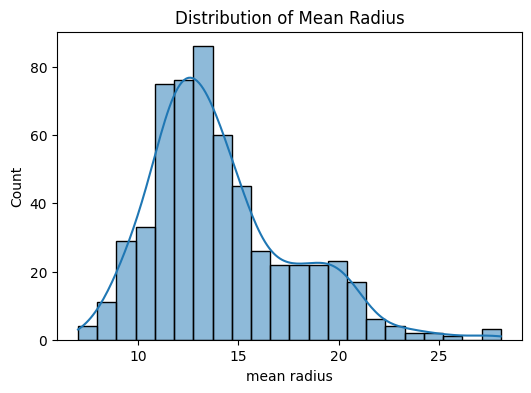

In [16]:
plt.figure(figsize=(6,4))
sns.histplot(df['mean radius'], kde=True)
plt.title("Distribution of Mean Radius")
plt.show()

Mean radius shows spread and variation across samples,
Helps understand feature distribution

<Axes: xlabel='mean radius'>

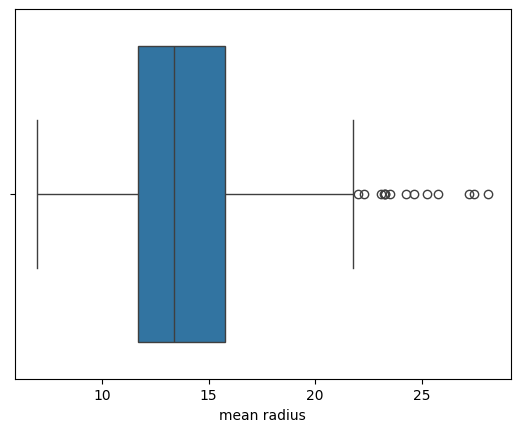

In [17]:
sns.boxplot(x=df['mean radius'])

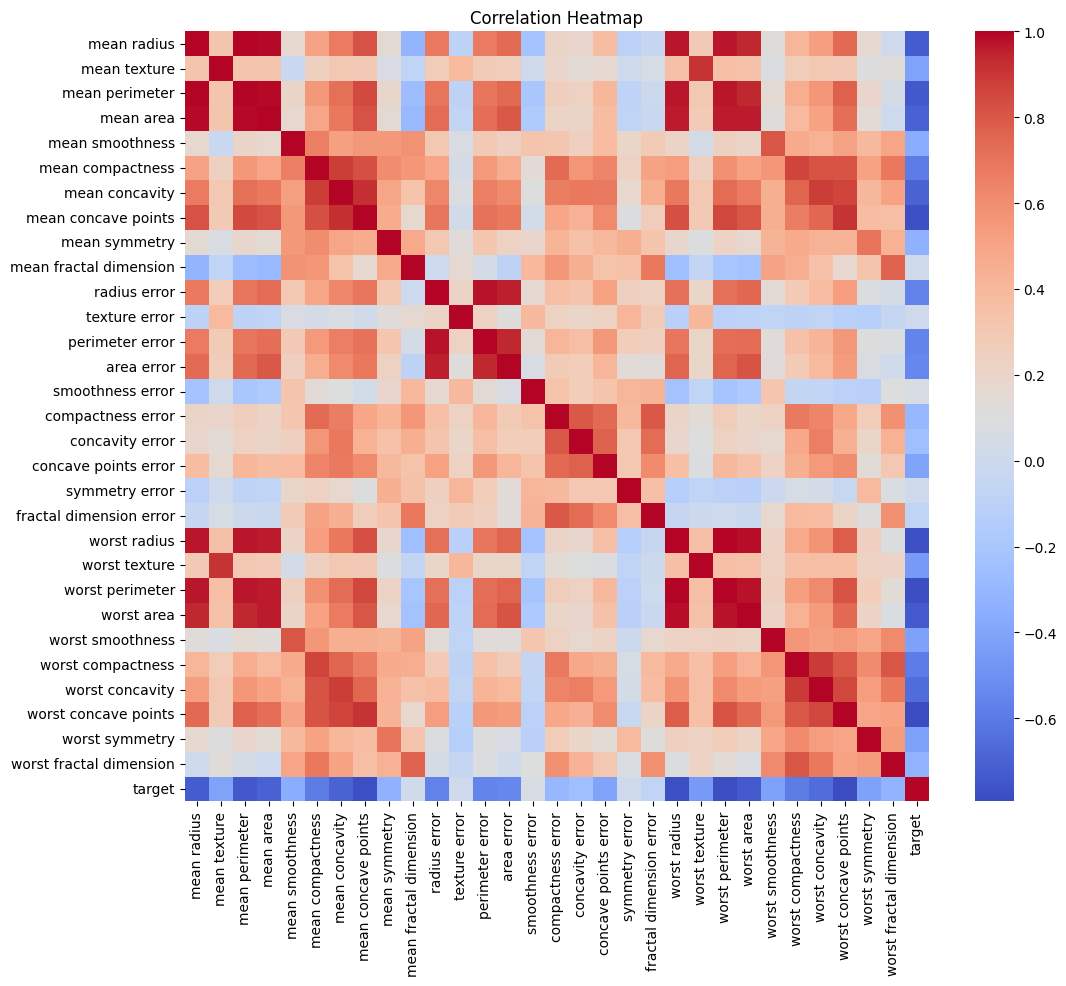

In [19]:
plt.figure(figsize=(12,10))
sns.heatmap(df.drop(['diagnosis'], axis=1).corr(), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

Strong correlation between radius, perimeter, and area

Indicates multicollinearity among features

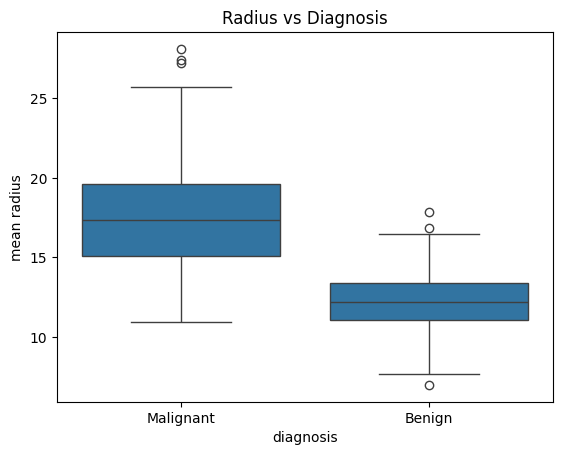

In [20]:
sns.boxplot(x='diagnosis', y='mean radius', data=df)
plt.title("Radius vs Diagnosis")
plt.show()

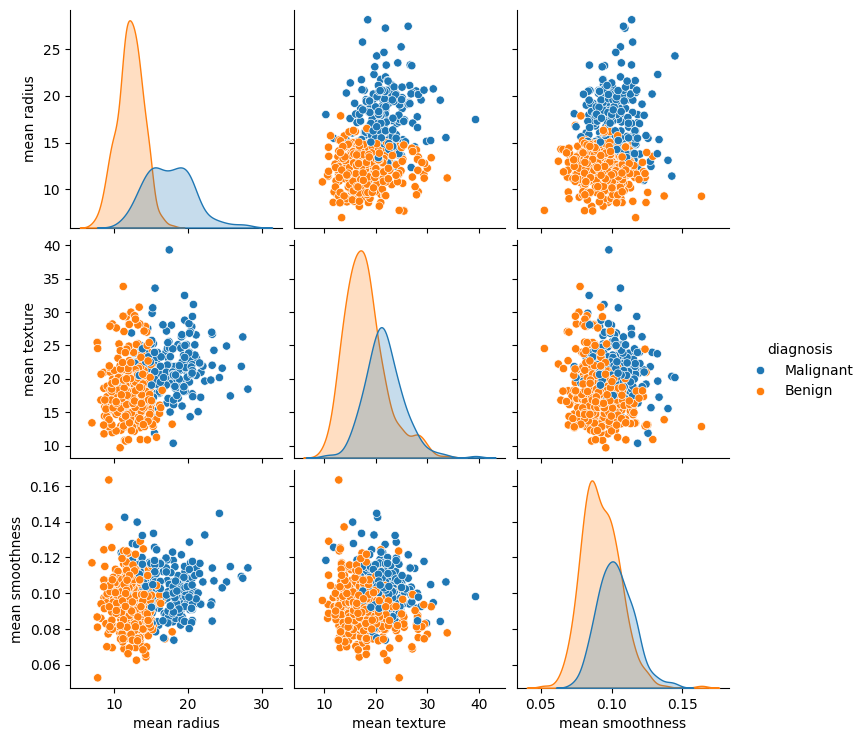

In [21]:
selected_features = ['mean radius', 'mean texture', 'mean smoothness', 'diagnosis']

sns.pairplot(df[selected_features], hue='diagnosis')
plt.show()

Clear separation between benign and malignant clusters

Confirms strong predictive power of selected features

In [22]:
from sklearn.model_selection import train_test_split

X = df.drop(['target', 'diagnosis'], axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [23]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=10000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=10000)

In [25]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9298245614035088
              precision    recall  f1-score   support

           0       0.90      0.90      0.90        39
           1       0.95      0.95      0.95        75

    accuracy                           0.93       114
   macro avg       0.92      0.92      0.92       114
weighted avg       0.93      0.93      0.93       114



Model achieves ~93% accuracy

High precision and recall indicate reliable predictions

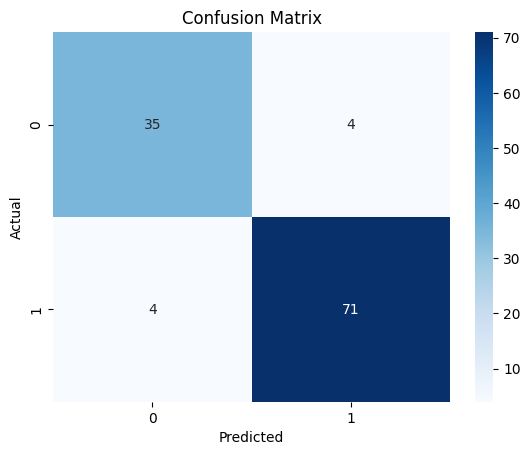

In [26]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

Most predictions are correct

Low number of misclassifications

##Final Conclusion
Dataset is clean and well-structured

Tumor size-related features are strong indicators of malignancy

Strong correlations exist among multiple features

EDA reveals clear separation between classes

Logistic Regression achieved ~93% accuracy

##This project demonstrates the ability to perform EDA, extract insights, and build a predictive model using real-world data.

## The model demonstrates how data analysis can support early cancer detection decisions.